# Poder Adquisitivo del Salario Mínimo en Colombia (2016–2025)
### ¿El colombiano promedio vive o sobrevive — y le alcanza para invertir en su futuro?

**Elaborado por:** Mauxy Salcedo  
**Año:** 2026  
**Herramientas:** Python · Pandas · Matplotlib · Seaborn · Jupyter Notebook  
**Fuentes de datos:** DANE · Banco de la República · Ministerio del Trabajo · SNIES

---

Este documento presenta los resultados del análisis. Si quieres ver el proceso completo de obtención, limpieza y cálculo de los datos, consulta el notebook técnico: `poderadquisitivo_listo.ipynb`

## Resumen del proyecto

Este proyecto analiza si el salario mínimo en Colombia ha mejorado, empeorado o se ha mantenido en cuanto al poder adquisitivo de las personas entre 2016 y 2025 — y si, después de cubrir lo básico, le queda algo al colombiano promedio para invertir en su educación superior.

El análisis se construyó en tres capas, cada una respondiendo una pregunta específica que conduce a la siguiente:

1. **¿El salario mínimo rinde más o menos que antes?** → Capa de salario real
2. **¿Después de cubrir lo básico, sobra algo?** → Capa de excedente (vivir o sobrevivir)
3. **¿Ese excedente alcanza para estudiar?** → Capa de inversión en educación superior

**Período analizado:** 2016 – 2025 (10 años)  
**Población de referencia:** trabajador formal colombiano que gana exactamente el salario mínimo mensual legal vigente (SMMLV)

## Hallazgos Principales

In [8]:
import pandas as pd

hallazgos = {
    "Indicador": [
        "Salario nominal (SMMLV)",
        "IPC (diciembre)",
        "Salario real (pesos constantes dic-2018)",
        "Auxilio de transporte",
        "Línea de pobreza nacional",
        "Ingreso total (salario + auxilio)",
        "Excedente mensual",
        "Excedente semestral"
    ],
    "2016": ["$689.455", "93,11", "$740.594", "$77.700", "$297.933", "$767.155", "$469.222", "$2.815.332"],
    "2025": ["$1.423.500", "152,27", "$934.853", "$200.000", "$482.041", "$1.623.500", "$1.141.459", "$6.848.754"],
    "Cambio": ["+106%", "+63,5%", "+26%", "+157%", "+62%", "+112%", "+143%", "+143%"]
}

df_hallazgos = pd.DataFrame(hallazgos)
df_hallazgos.style.set_properties(**{"text-align": "left"}).hide(axis="index")




Indicador,2016,2025,Cambio
Salario nominal (SMMLV),$689.455,$1.423.500,+106%
IPC (diciembre),"93,11","152,27","+63,5%"
Salario real (pesos constantes dic-2018),$740.594,$934.853,+26%
Auxilio de transporte,$77.700,$200.000,+157%
Línea de pobreza nacional,$297.933,$482.041,+62%
Ingreso total (salario + auxilio),$767.155,$1.623.500,+112%
Excedente mensual,$469.222,$1.141.459,+143%
Excedente semestral,$2.815.332,$6.848.754,+143%


## Herramientas y metodología

**Lenguaje:** Python 3  
**Librerías utilizadas:**
- `pandas` — carga, limpieza, transformación y cruce de los datos
- `numpy` — operaciones numéricas
- `matplotlib` y `seaborn` — visualizaciones
- `os` — manejo de rutas y carpetas

**Metodología:**
- **Deflactación del salario:** se dividió el salario nominal de cada año por el IPC de diciembre de ese año (÷100), usando la serie de empalme del DANE (base diciembre 2018 = 100)
- **Excedente:** (Salario nominal + Auxilio de transporte) − Línea de pobreza nacional, comparados en pesos corrientes del mismo año
- **Comparación con matrícula:** el excedente mensual se multiplicó por 6 (semestre) para compararlo en la misma unidad que el costo de matrícula universitaria

In [1]:
import pandas as pd
from IPython.display import Image, display

df_final = pd.read_csv("datos_poder_adquisitivo/tabla_maestra.csv")

## Tabla Maestra
Todos los indicadores del proyecto, año por año (2016–2025).

In [2]:
df_final.style.format({
    "Salario_nominal":      "${:,.0f}",
    "Auxilio_transporte":   "${:,.0f}",
    "IPC":                  "{:.2f}",
    "Salario_real":         "${:,.0f}",
    "Linea_pobreza":        "${:,.0f}",
    "Ingreso_total":        "${:,.0f}",
    "Excedente":            "${:,.0f}",
    "Excedente_semestral":  "${:,.0f}"
})

,Año,Salario_nominal,Auxilio_transporte,IPC,Mes_IPC,Salario_real,Linea_pobreza,Ingreso_total,Excedente,Excedente_semestral
0,2016,"$689,455","$77,700",93.11,Diciembre,"$740,474","$297,933","$767,155","$469,222","$2,815,332"
1,2017,"$737,717","$83,140",96.92,Diciembre,"$761,161","$306,653","$820,857","$514,204","$3,085,224"
2,2018,"$781,242","$88,211",100.00,Diciembre,"$781,242","$314,294","$869,453","$555,159","$3,330,954"
3,2019,"$828,116","$97,032",103.80,Diciembre,"$797,800","$325,145","$925,148","$600,003","$3,600,018"
4,2020,"$877,803","$102,854",105.48,Diciembre,"$832,199","$329,080","$980,657","$651,577","$3,909,462"
5,2021,"$908,526","$106,454",111.41,Diciembre,"$815,480","$351,480","$1,014,980","$663,500","$3,981,000"
6,2022,"$1,000,000","$117,172",126.03,Diciembre,"$793,462","$396,864","$1,117,172","$720,308","$4,321,848"
7,2023,"$1,160,000","$140,606",137.72,Diciembre,"$842,289","$435,375","$1,300,606","$865,231","$5,191,386"
8,2024,"$1,300,000","$162,000",144.88,Diciembre,"$897,294","$460,198","$1,462,000","$1,001,802","$6,010,812"
9,2025,"$1,423,500","$200,000",152.27,Diciembre,"$934,853","$482,041","$1,623,500","$1,141,459","$6,848,754"


## Capa 1 — Salario real
### ¿El salario mínimo rinde más o menos que antes?

El salario nominal subió 106% entre 2016 y 2025 — en papel, más del doble. Pero descontando la inflación, el salario real solo creció 26%: pasó de $740.594 a $934.853 (en pesos constantes de diciembre 2018). Esa brecha entre el 106% del decreto y el 26% real es exactamente por qué la gente siente que el aumento de enero nunca alcanza como debería.

**Respuesta:** sí mejoró, pero mucho menos de lo que parece.

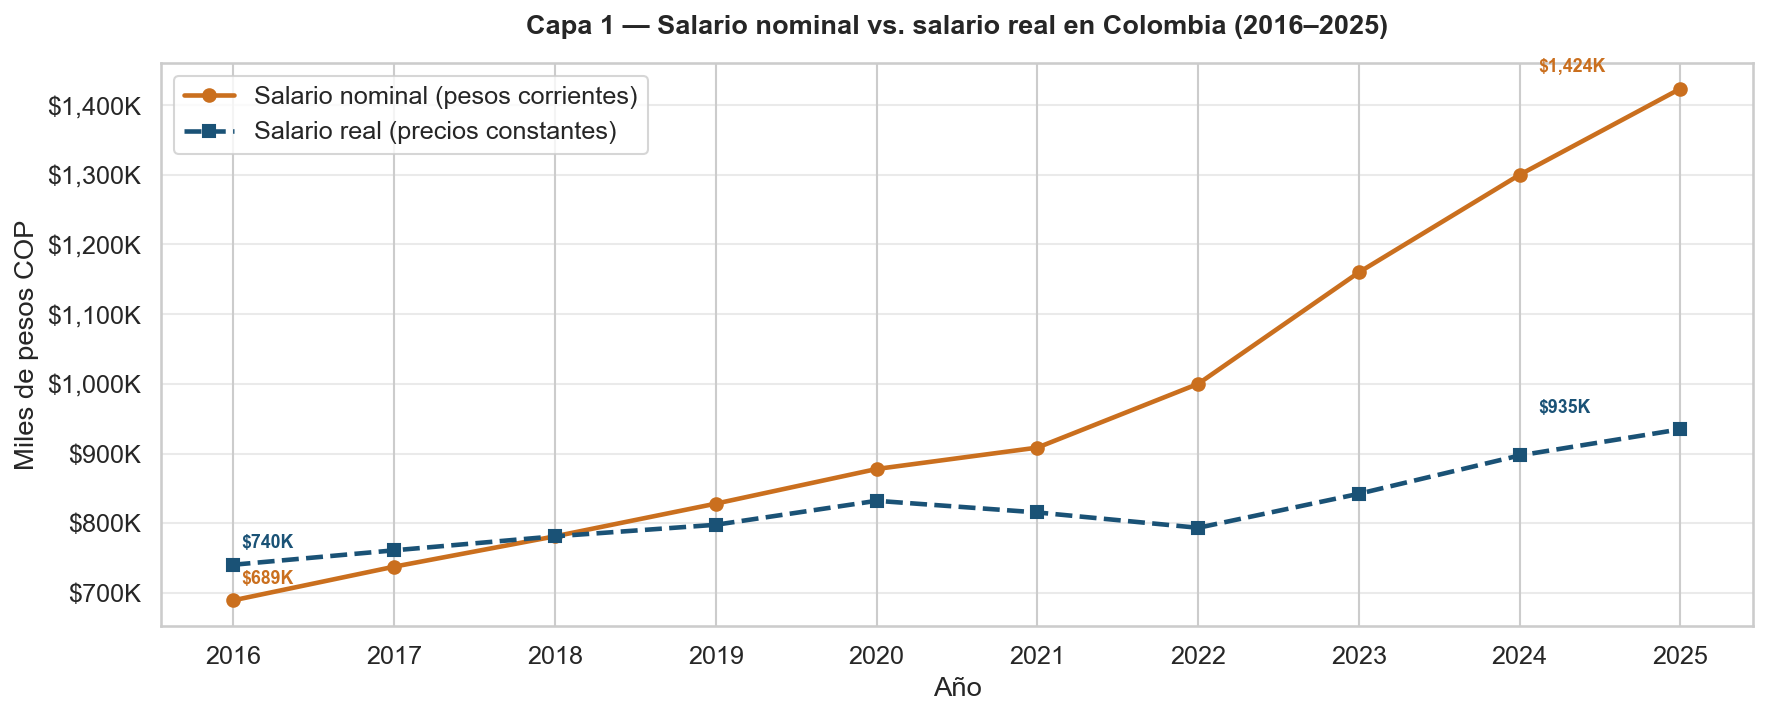

In [3]:
Image("datos_poder_adquisitivo/grafica_capa1_salario_real.png")

## Capa 2 — ¿Vivir o sobrevivir?
### ¿Cuánto le queda al colombiano promedio después de cubrir lo básico?

El ingreso total (salario + auxilio de transporte) se mantuvo por encima de la línea de pobreza en toda la década, pero el excedente es frágil. En 2022-2023, cuando la inflación fue más alta, ese margen se redujo notablemente. Y el excedente calculado aquí es para una sola persona: en Colombia, el hogar promedio tiene 2,82 integrantes (DANE, 2025) — cuando ese salario sostiene a tres personas, el margen individual que ves en la gráfica se divide, y el resultado puede ser un déficit.

**Respuesta:** técnicamente, una persona sola está por encima de la pobreza. Pero en la práctica familiar, el colchón es demasiado estrecho para absorber imprevistos — y para millones de hogares, ese colchón no existe.

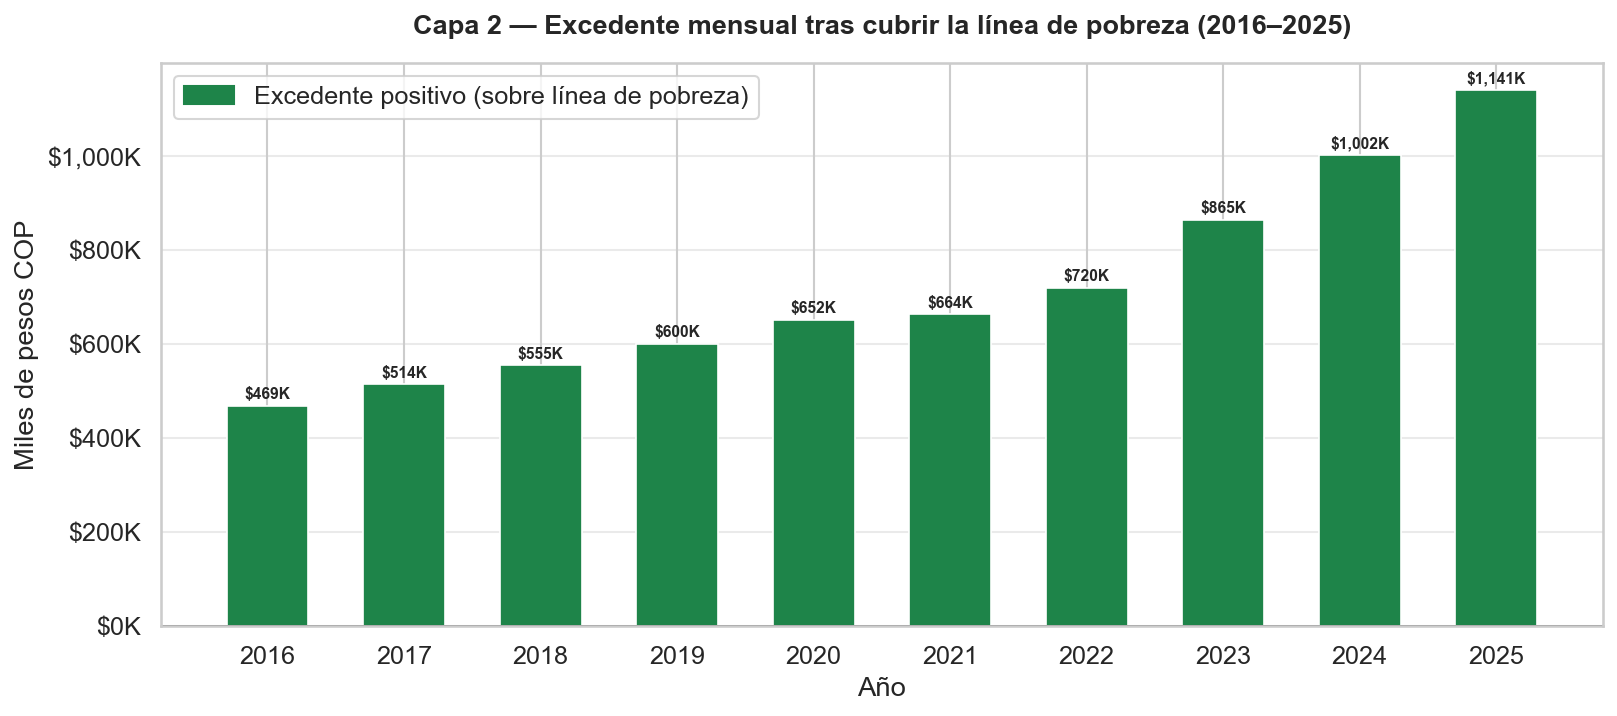

In [4]:
Image("datos_poder_adquisitivo/grafica_capa2_excedente.png")

## Capa 3 — ¿Invertir en el futuro?
### ¿Ese excedente alcanza para una matrícula universitaria?

El excedente semestral pasó de $2.815.332 en 2016 a $6.848.754 en 2025. El costo promedio de una matrícula en universidad privada (excluyendo Medicina) es de aproximadamente $8.500.000 por semestre. En ningún año del período analizado el excedente semestral alcanzó para cubrirla. La universidad pública con política de gratuidad — que cubre al 97% de los estudiantes de estrato 1, 2 y 3 — es, en la práctica, la única opción financieramente viable.

**Respuesta:** no alcanza para educación privada en ningún año. La educación pública gratuita no es una preferencia — es la única puerta abierta.

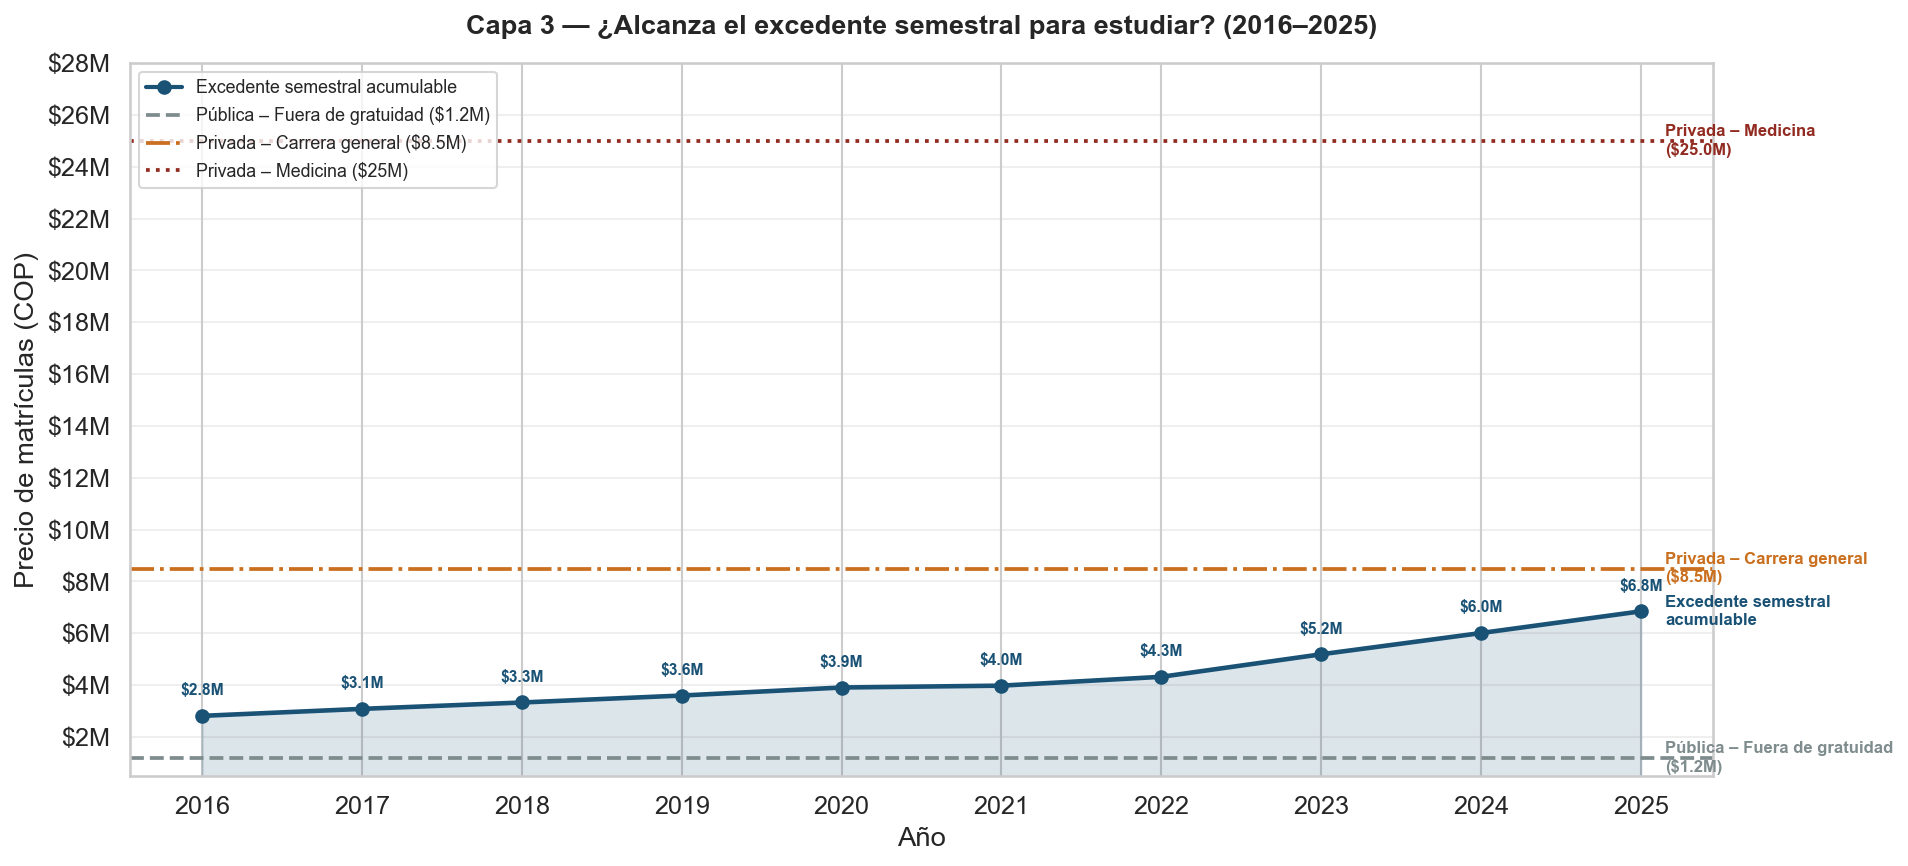

In [5]:
Image("datos_poder_adquisitivo/grafica_capa3_matricula.png")

##### Conclusiones

### ¿El salario mínimo en Colombia ha mejorado el poder adquisitivo entre 2016 y 2025?

**Capa 1 — Salario real: ¿el salario mínimo rinde más o menos que antes?**  
El salario nominal creció sustancialmente en la última década, pasando de $689.455 en 2016 a $1.423.500 en 2025 — un aumento de aproximadamente 106% en pesos corrientes. Pero ese número engaña: cuando se descuenta la inflación, el salario real pasó de aproximadamente $740.594 en 2016 a $934.853 en 2025 — un aumento real de solo 26%, menos de la cuarta parte de lo que sugiere el aumento nominal. El período 2021-2023 fue especialmente duro: la inflación superó ampliamente los aumentos nominales, erosionando el poder de compra. **Respuesta: el salario sí mejoró en términos reales, pero la diferencia entre el 106% en el papel y el 26% en la práctica es justamente la razón por la que la gente siente que el aumento de cada enero nunca alcanza como debería.**

**Capa 2 — ¿Vivir o sobrevivir?**  
El ingreso total (salario + auxilio de transporte) se ha mantenido por encima de la línea de pobreza en la mayor parte del período, pero el excedente es pequeño y vulnerable. En los años de alta inflación (2022-2023), el margen se redujo considerablemente. Y este excedente, calculado para una sola persona, es aún más frágil en la práctica: en Colombia, un hogar promedio está compuesto por 2,82 personas (DANE, 2025) — lo que significa que, con frecuencia, ese mismo salario mínimo no sostiene a una sola persona, sino que se reparte entre dos o tres. Cuando eso ocurre, el excedente individual se diluye hasta casi desaparecer. **Respuesta: técnicamente, una persona sola vive por encima de la pobreza — pero en la práctica, cuando ese ingreso debe sostener a una familia, el margen real es mucho menor de lo que las cifras individuales sugieren.**

**Capa 3 — ¿Invertir en el futuro?**  
El excedente semestral no alcanza, en ningún año del período, para pagar una matrícula en universidad privada — ni siquiera en las carreras más económicas. La universidad pública con política de gratuidad es, en la práctica, la única vía realista para que alguien que depende del salario mínimo acceda a educación superior sin endeudarse. **Respuesta: no, el salario mínimo por sí solo no alcanza para educación privada; la educación pública gratuita no es una opción entre varias, es la única puerta abierta.**

---

### Más allá del salario mínimo: el escenario más optimista posible

Es importante poner estos resultados en perspectiva. Todo este análisis se construyó sobre el caso de alguien que gana exactamente el salario mínimo, con empleo formal, y sin dependientes. Pero según datos del DANE (2025-2026), esa persona representa apenas el **10,1% de los trabajadores colombianos** (2,4 millones de personas).

El resto del país está distribuido así:
- **48,9% de los ocupados (11,38 millones de personas) gana menos del salario mínimo** — para ellos, el excedente que calculamos en este proyecto no solo es estrecho, es inexistente.
- **8,8% de la población económicamente activa está desempleada** (y esa cifra sube a 16-17% entre los jóvenes, justo la edad de quien aspira a la universidad).
- El resto gana entre 1 y más salarios mínimos — una minoría con algo más de margen.

En otras palabras: **este proyecto midió el mejor escenario posible.** Si incluso ahí el margen para invertir en educación es estrecho — y se diluye más cuando se reparte entre los 2,82 integrantes promedio de un hogar —, la realidad de casi la mitad del país es considerablemente más difícil que la que estos números muestran.

---

### Por qué la educación pública no es una opción, es una necesidad

Ante la ausencia de un excedente financiero real en los hogares colombianos que dependen de un salario mínimo o de ingresos informales, la educación pública se consolida no como una alternativa de preferencia, sino como una **necesidad de supervivencia social**. Colombia cuenta con cerca de 64 a 65 instituciones de educación superior públicas (87 en total incluyendo técnicas y tecnológicas, según el SNIES 2024), y gracias a la Política de Gratuidad ("Puedo Estudiar"), la matrícula es gratuita para cerca del 97% de los estudiantes de pregrado oficial — eliminando, al menos, el costo que este proyecto identificó como inalcanzable en la universidad privada.

Pero el sistema público tiene un cuello de botella real: según datos del Laboratorio de Economía de la Educación de la Universidad Javeriana (con base en cifras del SNIES), cerca de la mitad de quienes se postulan a una universidad pública no logra un cupo. Esto significa que la gratuidad resuelve el problema del dinero, pero no resuelve el problema del espacio.

En consecuencia, mientras el poder adquisitivo real del salario no permita un margen de inversión independiente, y la capacidad del sistema público no se amplíe sustancialmente, el acceso a la educación superior en Colombia seguirá siendo un privilegio condicionado por la geografía, el azar de la admisión, o el respaldo de redes de apoyo familiares.

---

### Conclusión final

Este estudio demuestra que el poder adquisitivo del salario mínimo en Colombia mejoró en la última década, pero de forma frágil, desigual, y muy por debajo de lo que sugiere el titular de cada enero: un aumento nominal de 106% se convierte, en la práctica, en apenas 26% de poder de compra real. El colombiano que gana el salario mínimo está, en el mejor de los casos, sobreviviendo con un margen estrecho que se diluye aún más cuando ese ingreso sostiene a una familia — y para casi la mitad del país, que gana menos que eso, ese margen ni siquiera existe.

En este contexto, la educación superior deja de ser una simple aspiración personal y se convierte en la variable que decide si alguien puede romper o no el ciclo en el que nació. No es un lujo ni una opción entre varias: es, junto con el apoyo familiar y las pocas becas disponibles, una de las pocas rutas reales de movilidad social que le quedan a un país donde la mayoría de sus trabajadores no gana lo suficiente para invertir en su propio futuro. Por eso, fortalecer y ampliar el acceso a la universidad pública no es una política social más — es, para millones de colombianos, la diferencia entre quedarse donde están o construir algo distinto.

---
*Fuentes: DANE (IPC, Líneas de pobreza, mercado laboral, informalidad, Encuesta Nacional de Calidad de Vida), Banrep / Ministerio del Trabajo (SMMLV y Auxilio de transporte), SNIES / Laboratorio de Economía de la Educación – Universidad Javeriana, Ministerio de Educación Nacional (cifras de matrícula 2024), datos de matrículas universitarias Colombia 2024-2026.*  
*Elaborado por: Mauxy Salcedo — Proyecto de portafolio, 2026.*